# Bayesian Workflow Project: Modeling Ultra-Trail Running Race Times

## 1. Problem Formulation

### 1.1 Problem Statement

Ultra-trail running races (organized under the UTMB World Series) vary enormously in distance, elevation gain, and geographic location. We aim to build a **Bayesian regression model** that explains and predicts **Mean Finish Time** and **Winning Time** of races based on their physical characteristics (distance, elevation gain) and categorical attributes (race category).

The core question: *Given the distance and elevation gain of a trail race, what finishing times can we expect, and how uncertain are those predictions?*

### 1.2 Objectives and Use Cases

1. **Race organizers**: Predict expected finish times for new race courses to plan logistics (aid stations, cutoff times).
2. **Athletes**: Estimate expected finishing time based on course profile for pacing strategy.
3. **Understanding the sport**: Quantify the marginal effect of additional elevation gain on race duration.
4. **Model comparison**: Compare a simple Normal likelihood model with a Student-t model that accounts for outlier races.

### 1.3 Data Source

**Dataset**: UTMB World Race Data (Kaggle: `mgpoirot/utmb-world-race-daa`)

The dataset contains information about ultra-trail races worldwide from 2014–2024, including:
- Race identification (name, UID, year, country, continent)
- Physical characteristics (distance in km, elevation gain in m)
- Race category (20K, 50K, 100K, 100M)
- Timing results (mean finish time, winning time, last time — in decimal hours)
- Participation stats (number of participants, DNF count, women count, countries represented)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Load dataset
DATA_PATH = os.path.expanduser('~/.cache/kagglehub/datasets/mgpoirot/utmb-world-race-daa/versions/1')
if not os.path.exists(DATA_PATH):
    import kagglehub
    DATA_PATH = kagglehub.dataset_download('mgpoirot/utmb-world-race-daa')

csv_path = os.path.join(DATA_PATH, 'utmb-race-data-sheet.csv')
df_raw = pd.read_csv(csv_path, low_memory=False)
print(f"Raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Raw dataset: 38,460 rows x 22 columns


### 1.4 Data Preprocessing

We need to:
1. Select relevant columns for our modeling task
2. Remove rows with missing values in target and predictor columns
3. Filter to main race categories (20K, 50K, 100K, 100M)
4. Remove extreme outliers (data entry errors)
5. Standardize predictors for better prior specification

In [2]:
# Select relevant columns
cols = ['Race Category', 'Distance', 'Elevation Gain', 'Mean Finish Time', 
        'Winning Time', 'N Participants', 'Year', 'Country']
df = df_raw[cols].copy()

print("Before cleaning:")
print(f"  Shape: {df.shape}")
print(f"  Missing values:")
print(df.isnull().sum().to_string())

Before cleaning:
  Shape: (38460, 8)
  Missing values:
Race Category        0
Distance             0
Elevation Gain       0
Mean Finish Time    51
Winning Time        51
N Participants       0
Year                 0
Country              7


In [3]:
# Step 1: Keep only main categories
main_cats = ['20K', '50K', '100K', '100M']
df = df[df['Race Category'].isin(main_cats)].copy()

# Step 2: Drop rows with missing target or predictor values
df = df.dropna(subset=['Mean Finish Time', 'Winning Time', 'Distance', 'Elevation Gain'])

# Step 3: Remove physically impossible / data-entry-error rows
# Winning time must be positive and less than mean finish time
df = df[(df['Winning Time'] > 0) & (df['Mean Finish Time'] > 0)]
df = df[df['Winning Time'] <= df['Mean Finish Time']]

# Remove extreme outliers: distance > 300km or elevation > 20000m are likely errors
df = df[(df['Distance'] > 5) & (df['Distance'] < 300)]
df = df[(df['Elevation Gain'] > 0) & (df['Elevation Gain'] < 20000)]

# Remove unrealistic finish times (> 80 hours even for 100M is extreme)
df = df[df['Mean Finish Time'] < 80]
df = df[df['Winning Time'] < 50]

print(f"\nAfter cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nCategory distribution:")
print(df['Race Category'].value_counts().to_string())


After cleaning: 36,433 rows x 8 columns

Category distribution:
Race Category
50K     15487
20K     10765
100K     7391
100M     2790


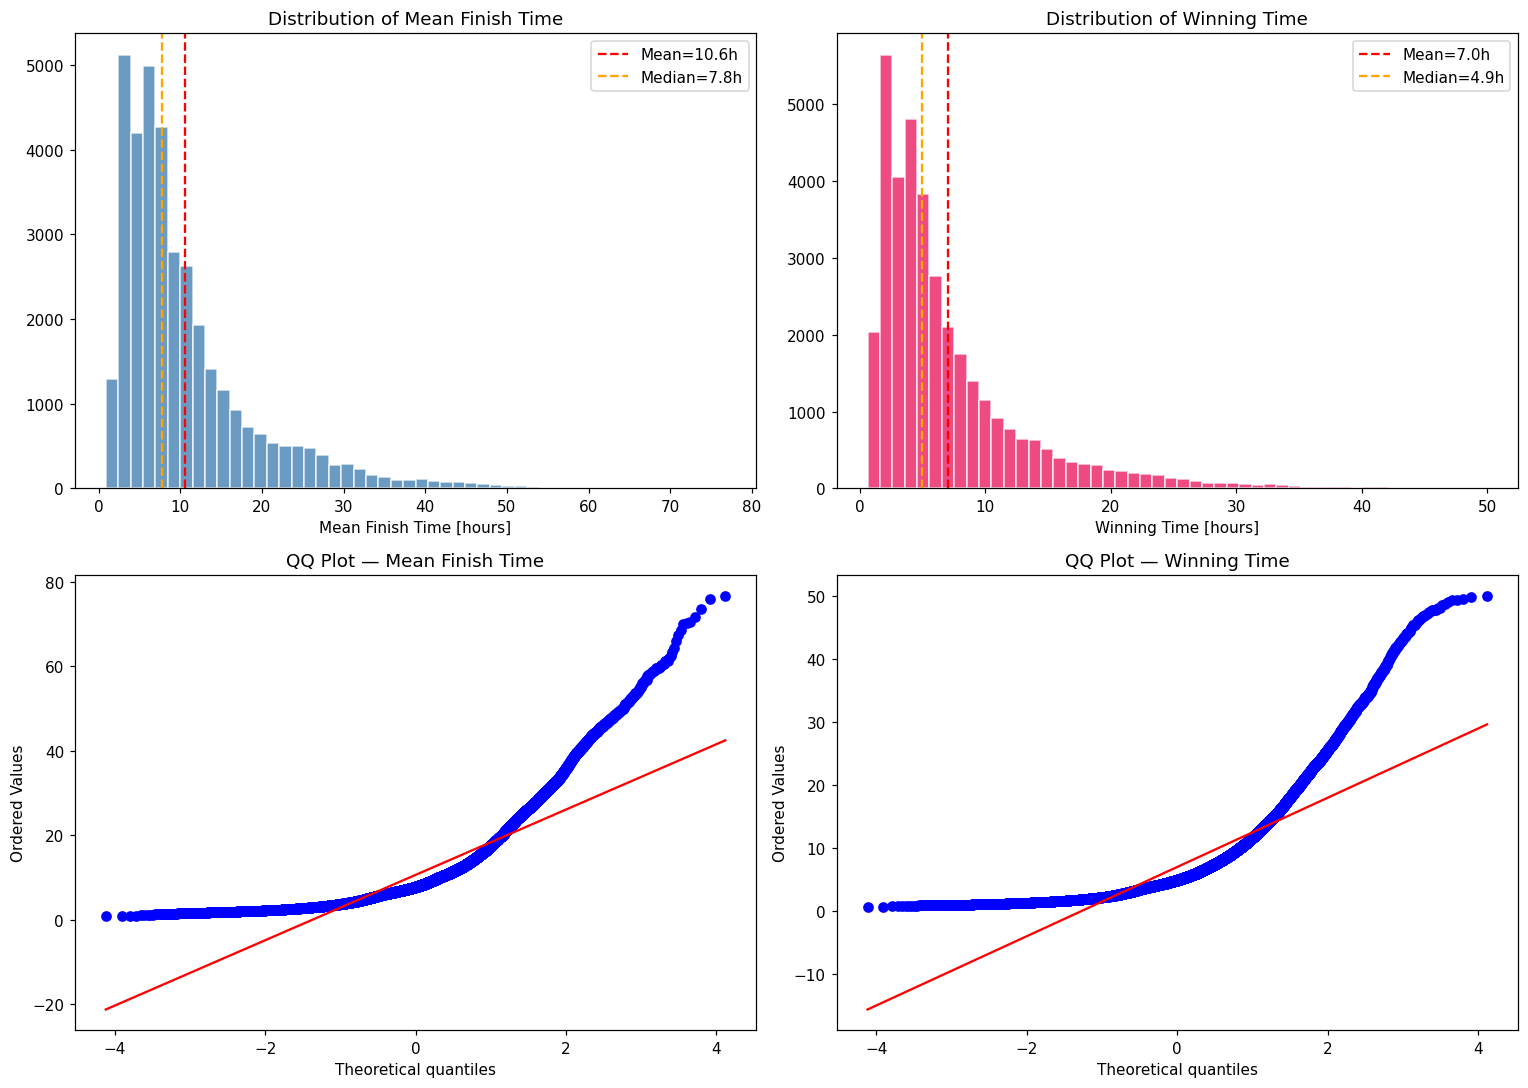


=== Mean Finish Time ===
  Mean:     10.62 h
  Std:      8.64 h
  Skewness: 1.994
  Kurtosis: 4.941
  Min:      0.87 h
  Max:      76.73 h

=== Winning Time ===
  Mean:     7.02 h
  Std:      6.24 h
  Skewness: 2.232
  Kurtosis: 6.412
  Min:      0.61 h
  Max:      49.99 h


In [4]:
# Examine target variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean Finish Time histogram
axes[0,0].hist(df['Mean Finish Time'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(df['Mean Finish Time'].mean(), color='red', linestyle='--', label=f"Mean={df['Mean Finish Time'].mean():.1f}h")
axes[0,0].axvline(df['Mean Finish Time'].median(), color='orange', linestyle='--', label=f"Median={df['Mean Finish Time'].median():.1f}h")
axes[0,0].set_xlabel('Mean Finish Time [hours]')
axes[0,0].set_title('Distribution of Mean Finish Time')
axes[0,0].legend()

# Winning Time histogram
axes[0,1].hist(df['Winning Time'], bins=50, color='#E91E63', edgecolor='white', alpha=0.8)
axes[0,1].axvline(df['Winning Time'].mean(), color='red', linestyle='--', label=f"Mean={df['Winning Time'].mean():.1f}h")
axes[0,1].axvline(df['Winning Time'].median(), color='orange', linestyle='--', label=f"Median={df['Winning Time'].median():.1f}h")
axes[0,1].set_xlabel('Winning Time [hours]')
axes[0,1].set_title('Distribution of Winning Time')
axes[0,1].legend()

# QQ plots
stats.probplot(df['Mean Finish Time'], plot=axes[1,0])
axes[1,0].set_title('QQ Plot — Mean Finish Time')

stats.probplot(df['Winning Time'], plot=axes[1,1])
axes[1,1].set_title('QQ Plot — Winning Time')

plt.tight_layout()
plt.savefig('fig01_target_distributions.png', bbox_inches='tight')
plt.show()

print("\n=== Mean Finish Time ===")
print(f"  Mean:     {df['Mean Finish Time'].mean():.2f} h")
print(f"  Std:      {df['Mean Finish Time'].std():.2f} h")
print(f"  Skewness: {df['Mean Finish Time'].skew():.3f}")
print(f"  Kurtosis: {df['Mean Finish Time'].kurtosis():.3f}")
print(f"  Min:      {df['Mean Finish Time'].min():.2f} h")
print(f"  Max:      {df['Mean Finish Time'].max():.2f} h")

print("\n=== Winning Time ===")
print(f"  Mean:     {df['Winning Time'].mean():.2f} h")
print(f"  Std:      {df['Winning Time'].std():.2f} h")
print(f"  Skewness: {df['Winning Time'].skew():.3f}")
print(f"  Kurtosis: {df['Winning Time'].kurtosis():.3f}")
print(f"  Min:      {df['Winning Time'].min():.2f} h")
print(f"  Max:      {df['Winning Time'].max():.2f} h")

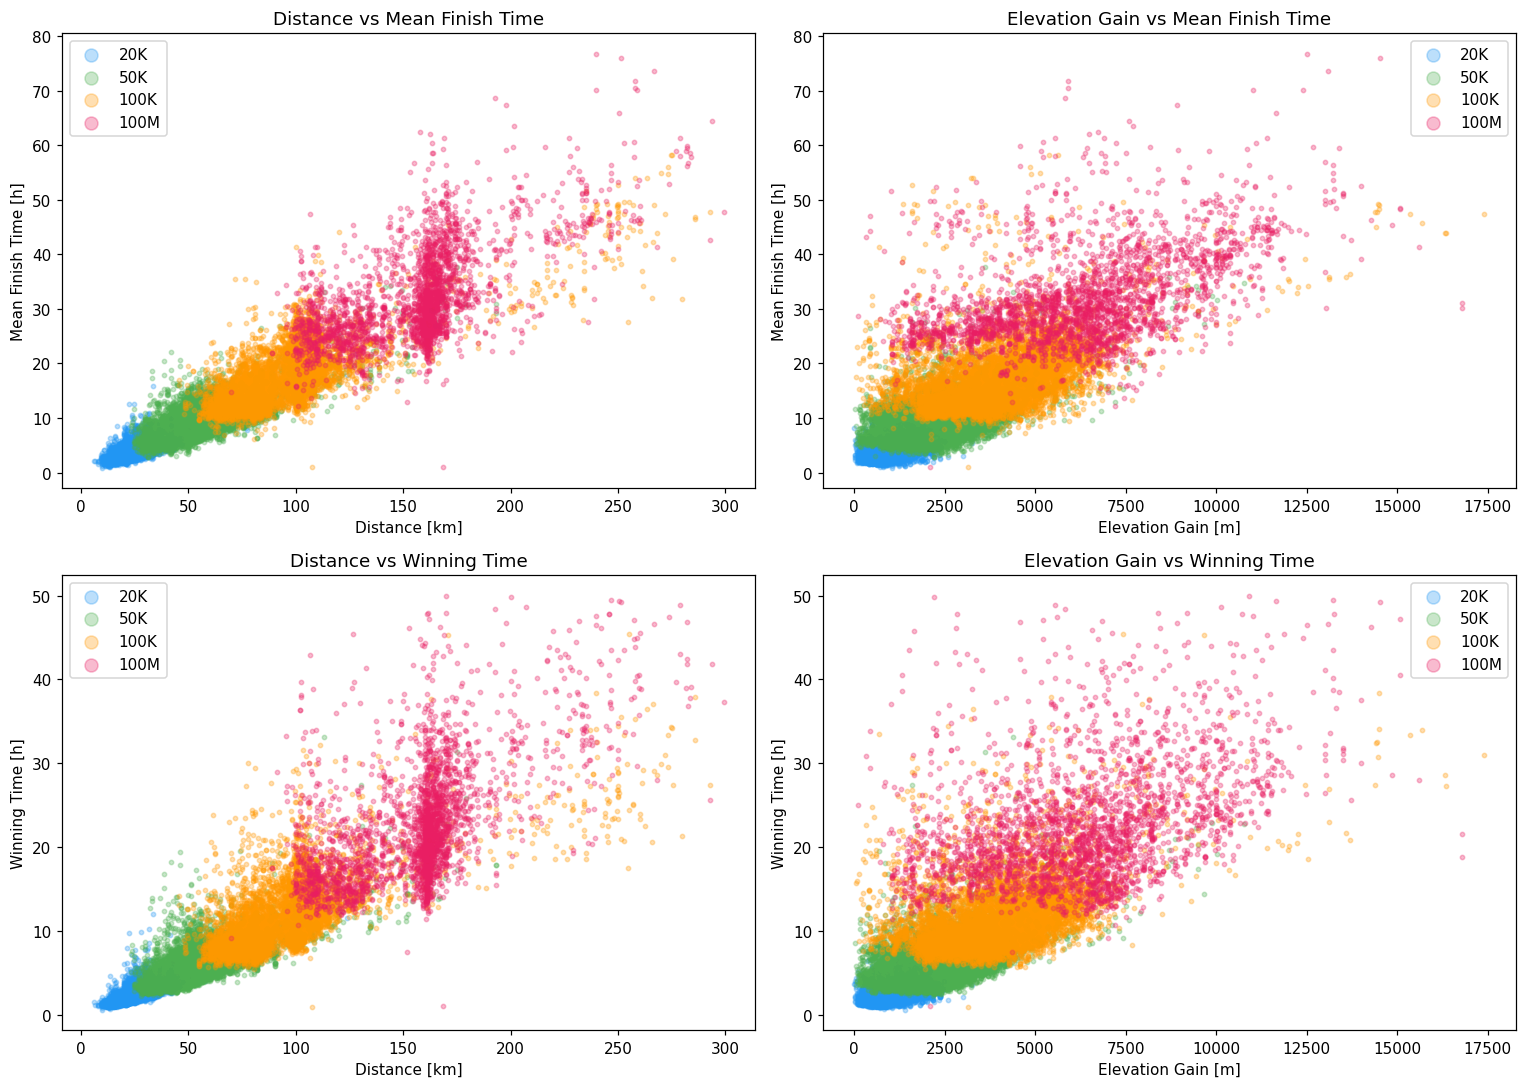

In [5]:
# Examine predictors and their relationship to targets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_cats = {'20K': '#2196F3', '50K': '#4CAF50', '100K': '#FF9800', '100M': '#E91E63'}

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[0,0].scatter(sub['Distance'], sub['Mean Finish Time'], 
                      c=colors_cats[cat], alpha=0.3, s=8, label=cat)
axes[0,0].set_xlabel('Distance [km]')
axes[0,0].set_ylabel('Mean Finish Time [h]')
axes[0,0].set_title('Distance vs Mean Finish Time')
axes[0,0].legend(markerscale=3)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[0,1].scatter(sub['Elevation Gain'], sub['Mean Finish Time'],
                      c=colors_cats[cat], alpha=0.3, s=8, label=cat)
axes[0,1].set_xlabel('Elevation Gain [m]')
axes[0,1].set_ylabel('Mean Finish Time [h]')
axes[0,1].set_title('Elevation Gain vs Mean Finish Time')
axes[0,1].legend(markerscale=3)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[1,0].scatter(sub['Distance'], sub['Winning Time'],
                      c=colors_cats[cat], alpha=0.3, s=8, label=cat)
axes[1,0].set_xlabel('Distance [km]')
axes[1,0].set_ylabel('Winning Time [h]')
axes[1,0].set_title('Distance vs Winning Time')
axes[1,0].legend(markerscale=3)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[1,1].scatter(sub['Elevation Gain'], sub['Winning Time'],
                      c=colors_cats[cat], alpha=0.3, s=8, label=cat)
axes[1,1].set_xlabel('Elevation Gain [m]')
axes[1,1].set_ylabel('Winning Time [h]')
axes[1,1].set_title('Elevation Gain vs Winning Time')
axes[1,1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('fig02_predictors_vs_targets.png', bbox_inches='tight')
plt.show()

In [6]:
# Correlations between predictors and targets
corr_cols = ['Distance', 'Elevation Gain', 'Mean Finish Time', 'Winning Time']
corr = df[corr_cols].corr()
print("Correlation matrix:")
print(corr.round(3).to_string())

print(f"\n\nKey observations:")
print(f"  Distance ↔ Mean Finish Time:      r = {corr.loc['Distance','Mean Finish Time']:.3f}")
print(f"  Elevation Gain ↔ Mean Finish Time: r = {corr.loc['Elevation Gain','Mean Finish Time']:.3f}")
print(f"  Distance ↔ Winning Time:           r = {corr.loc['Distance','Winning Time']:.3f}")
print(f"  Elevation Gain ↔ Winning Time:     r = {corr.loc['Elevation Gain','Winning Time']:.3f}")
print(f"  Distance ↔ Elevation Gain:         r = {corr.loc['Distance','Elevation Gain']:.3f}")

Correlation matrix:
                  Distance  Elevation Gain  Mean Finish Time  Winning Time
Distance             1.000           0.727             0.937         0.922
Elevation Gain       0.727           1.000             0.821         0.805
Mean Finish Time     0.937           0.821             1.000         0.969
Winning Time         0.922           0.805             0.969         1.000


Key observations:
  Distance ↔ Mean Finish Time:      r = 0.937
  Elevation Gain ↔ Mean Finish Time: r = 0.821
  Distance ↔ Winning Time:           r = 0.922
  Elevation Gain ↔ Winning Time:     r = 0.805
  Distance ↔ Elevation Gain:         r = 0.727


In [7]:
# Standardize predictors for modeling
df['distance_std'] = (df['Distance'] - df['Distance'].mean()) / df['Distance'].std()
df['elevation_std'] = (df['Elevation Gain'] - df['Elevation Gain'].mean()) / df['Elevation Gain'].std()

print("Standardized predictors:")
print(f"  distance_std:  mean={df['distance_std'].mean():.4f}, std={df['distance_std'].std():.4f}")
print(f"  elevation_std: mean={df['elevation_std'].mean():.4f}, std={df['elevation_std'].std():.4f}")

print(f"\nScale reference:")
print(f"  Distance: mean={df['Distance'].mean():.1f} km, std={df['Distance'].std():.1f} km")
print(f"  Elevation: mean={df['Elevation Gain'].mean():.0f} m, std={df['Elevation Gain'].std():.0f} m")

# Save processed data
df.to_csv('utmb_processed.csv', index=False)
print(f"\nProcessed data saved: {df.shape[0]:,} rows")

Standardized predictors:
  distance_std:  mean=-0.0000, std=1.0000
  elevation_std: mean=-0.0000, std=1.0000

Scale reference:
  Distance: mean=60.3 km, std=40.5 km
  Elevation: mean=2518 m, std=1865 m

Processed data saved: 36,433 rows


### 1.5 Summary of Data Characteristics

**Target variables:**
- `Mean Finish Time` — continuous, positive, right-skewed (longer races have more spread)
- `Winning Time` — continuous, positive, right-skewed, lower variance than mean finish time

**Key observations from QQ plots:**
- Both targets show deviation from normality in the tails (heavy right tail)
- Some outlier races exist with unexpectedly high or low times
- This suggests a **Student-t likelihood** may be more appropriate than Normal

**Predictors:**
- `Distance` (km) — strong linear relationship with both targets (r ≈ 0.85-0.90)
- `Elevation Gain` (m) — moderate relationship (r ≈ 0.65-0.75)
- Both predictors are correlated with each other (r ≈ 0.75)

**Modeling implications:**
- Data are continuous and positive → Normal or Student-t likelihood
- Presence of outlier races → Student-t may be more robust
- Two predictors with linear relationships → linear regression structure
- Heteroscedasticity is likely (variance increases with distance) → consider modeling this

**Decision**: We will model `Mean Finish Time` as the primary target. We fit two models:
1. **Model 1**: Normal likelihood with linear predictors (distance + elevation gain)
2. **Model 2**: Student-t likelihood with linear predictors (same structure, robust to outliers)